In [34]:
import jax

import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from functools import partial
from itertools import product

In [220]:
def free_RHS(t,y,b):
    v, w = y
    return (
        v - v**3/3 -w,
        v - b*w,
    )

def eigenval(c):
    return (
        -c/2 + jnp.sqrt(c**2/4+c),
        -c/2 - jnp.sqrt(c**2/4+c),
    )

def fixed(b):

    v_bar = np.sqrt(3 * (b-1)/b)
    w_bar = v_bar/b
    return (
        v_bar,
        w_bar
    )

def compute_separatrix(J):
    _, rev = np.linalg.eig(J)
    y0=rev[0]*1e-2
    res = solve_ivp(RHS, t_span=[0,-3.8,], y0=y0, method='BDF')
    return res.y

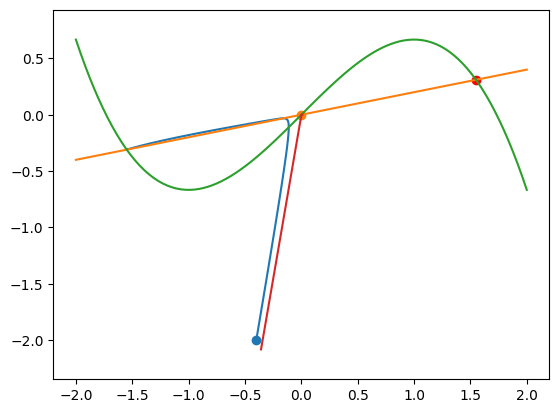

In [230]:
b =5
J = np.array([
    [1,-1],[1,-b]
])

RHS = partial(free_RHS, b=b)


y0=[-0.4,-2.,]
res = solve_ivp(RHS, t_span=[0,200,], y0=y0, method='BDF')


ax = plt.figure().add_subplot()
ax.plot(*res.y)
ax.scatter(*y0)
ax.scatter(*fixed(b), c='red')
ax.scatter(0,0)

vs = np.linspace(-2,2,100)
ax.plot(vs, vs/b)
ax.plot(vs, vs - vs**3/3)

ax.axis('equal')
ax.plot(*compute_separatrix(J))
# ax.set_xlim(-2,2)
# ax.set_ylim(-2,2)